# A/B Experiment Statistical Power Simulations — Explained

This notebook explores frequentist A/B testing using **Monte Carlo simulation** to empirically validate analytical statistical formulas. Each simulation is designed to confirm — or stress-test — a theoretical result.

## Topics Covered

| # | Section | Key Question |
|---|---------|-------------|
| 1 | **Power & Sample Size Planning** | How many users do we need to detect a given effect? |
| 2 | **Power Simulation Grid** | Does the analytical formula hold across effect sizes and sample sizes? |
| 3 | **Confidence Interval Behavior** | How do CIs distribute across repeated experiments? |
| 4 | **Non-parametric Testing (Mann-Whitney U)** | When should we use a distribution-free test? |
| 5 | **A/A Testing & Optional Stopping** | Is our false positive rate calibrated? What happens when we peek? |

## Key Statistical Definitions

| Symbol | Name | Typical Value | Meaning |
|--------|------|---------------|---------|
| α | Significance level | 0.05 – 0.10 | P(Type I error) = P(reject H₀ \| H₀ true) — false positive rate |
| β | Type II error rate | 0.20 | P(Type II error) = P(fail to reject H₀ \| H₁ true) — false negative rate |
| 1 − β | Statistical power | 0.80 | P(reject H₀ \| H₁ true) — true positive rate |
| MDE | Minimum Detectable Effect | experiment-specific | Smallest **relative** uplift the test is designed to detect |
| p₀ | Base conversion rate | experiment-specific | Baseline metric in the control group |
| CI | Confidence Interval | — | Range that contains the true parameter in (1−α)% of repeated experiments |

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm

from scipy.stats import norm, mannwhitneyu, chi2_contingency

# Import core stat helpers from exp_tools; local simulation wrappers are defined below
from exp_tools.stat_tools import get_df_stats, improv_interval_binomial, confidence_interval_ratio

pd.set_option('display.max_colwidth', None)

---
## Section 1: Statistical Power & Sample Size Planning

### The Two-Proportion Z-Test Power Formula

For a binary conversion metric comparing:
- **Control**: conversion rate p₀ (baseline)
- **Treatment**: conversion rate p₁ = p₀(1 + δ), where δ is the expected relative uplift

The **Minimum Detectable Effect (MDE)** in absolute terms is:

$$\Delta = p_1 - p_0 = p_0 \cdot \delta$$

Under the null hypothesis H₀: p₁ = p₀, both groups share variance σ² = p₀(1−p₀) (Bernoulli variance). The required sample size **per variant** to detect Δ with significance α and power 1−β is:

$$n_{\text{variant}} = \frac{2\sigma^2 \left(z_{\alpha/2} + z_\beta\right)^2}{\Delta^2}$$

where:
- $z_{\alpha/2} = \Phi^{-1}(1 - \alpha/2)$ — critical value for the two-sided test (e.g., 1.96 for α = 0.05)
- $z_\beta = \Phi^{-1}(1-\beta)$ — critical value for the desired power (e.g., 0.842 for 80% power)
- $\sigma^2 = p_0(1-p_0)$ — **pooled variance approximation** (assumes both groups have equal variance ≈ control variance)

**Why the factor of 2?** The variance of the difference of two independent proportions is:
$$\text{Var}[\hat{p}_1 - \hat{p}_0] = \frac{\sigma^2}{n} + \frac{\sigma^2}{n} = \frac{2\sigma^2}{n}$$

Note that this formula yields the **per-variant** sample size. Total experiment traffic = 2 × n_variant.

### Inverting: MDE Given Fixed Traffic

When traffic is fixed, solve for the MDE:

$$\Delta = \sigma \sqrt{\frac{2(z_{\alpha/2} + z_\beta)^2}{n_{\text{variant}}}} \quad \Rightarrow \quad \delta_{\text{MDE}} = \frac{\Delta}{p_0}$$

In [2]:
def calculate_req_traffic_for_power(alpha, beta, base_rate, expected_effect):
    """
    Compute required sample size per variant for a two-proportion z-test.

    Uses a pooled variance approximation (variance estimated from the control rate).
    This is the standard formula for binary metrics and is conservative when
    the relative effect size is small.

    Parameters
    ----------
    alpha : float
        Significance level (two-sided), e.g. 0.05.
    beta : float
        Type II error rate (1 - power), e.g. 0.20 for 80% power.
    base_rate : float
        Baseline conversion rate p0 in the control group.
    expected_effect : float
        Expected relative uplift delta (e.g. 0.05 for 5% relative increase).
        The absolute MDE is base_rate * expected_effect.

    Returns
    -------
    int
        Required sample size per variant.
    """
    za = norm.ppf(1 - alpha / 2)           # e.g. 1.96 for alpha=0.05
    zb = norm.ppf(1 - beta)                # e.g. 0.842 for 80% power
    mde = base_rate * expected_effect      # absolute MDE: p0 * delta
    sigma_sq = base_rate * (1 - base_rate) # Var[Bernoulli(p0)]
    n_variant = 2 * sigma_sq * (za + zb)**2 / mde**2
    return int(n_variant)


def calculate_mde_from_traffic(alpha, beta, base_rate, n_variant):
    """
    Compute the relative MDE achievable with a given fixed sample size.

    This is the inverse of calculate_req_traffic_for_power: given a sample
    size constraint, returns the smallest relative effect that the experiment
    can reliably detect.

    Parameters
    ----------
    alpha : float
        Significance level (two-sided).
    beta : float
        Type II error rate (1 - power).
    base_rate : float
        Baseline conversion rate in the control group.
    n_variant : int
        Available sample size per variant.

    Returns
    -------
    float
        Minimum detectable relative effect (e.g. 0.05 means 5% relative uplift).
    """
    za = norm.ppf(1 - alpha / 2)
    zb = norm.ppf(1 - beta)
    sigma_sq = base_rate * (1 - base_rate)
    mde_abs = np.sqrt(2 * sigma_sq * (za + zb)**2 / n_variant)
    return mde_abs / base_rate  # convert absolute MDE to relative

In [3]:
# --- Experiment Design Parameters ---
ALPHA      = 0.05   # significance level (two-sided)
BETA       = 0.20   # type II error rate  (1 - power = 1 - 0.80)
BASE_RATE  = 0.05   # baseline conversion rate: 5%
EXPECTED_UPLIFT_PERC = 0.05  # minimum relative effect to detect: 5%
N_VARIANTS = 2      # control + 1 treatment
N_DAYS     = 14     # planned experiment duration

mde_abs = BASE_RATE * EXPECTED_UPLIFT_PERC
print(f"MDE (absolute) = +/- {mde_abs:.2%}")
print(f"Detectable range: [{BASE_RATE - mde_abs:.2%}, {BASE_RATE + mde_abs:.2%}]")
print("------")

req_per_variant = calculate_req_traffic_for_power(
    alpha=ALPHA, beta=BETA, base_rate=BASE_RATE, expected_effect=EXPECTED_UPLIFT_PERC
)
req_daily = req_per_variant / N_DAYS

print(f"\n{req_per_variant:,}  \t=== Required visitors per variant")
print(f"{req_daily:,.0f}  \t=== Required daily visitors per variant over {N_DAYS} days")
print(f"{req_per_variant * N_VARIANTS:,}  \t=== Total required visitors across both variants")

# Roundtrip validation: feeding n back into MDE formula should recover the original effect
mde_roundtrip = calculate_mde_from_traffic(
    alpha=ALPHA, beta=BETA, base_rate=BASE_RATE, n_variant=req_per_variant
)
print(f"\nRoundtrip check — MDE from n: {mde_roundtrip:.5f}  (expected: {EXPECTED_UPLIFT_PERC:.5f})")
assert abs(mde_roundtrip - EXPECTED_UPLIFT_PERC) < 1e-3, "Roundtrip mismatch!"
print("Roundtrip verified: calculate_mde_from_traffic is the inverse of calculate_req_traffic_for_power")

MDE (absolute) = +/- 0.25%
Detectable range: [4.75%, 5.25%]
------

119,302  	=== Required visitors per variant
8,522  	=== Required daily visitors per variant over 14 days
238,604  	=== Total required visitors across both variants

Roundtrip check — MDE from n: 0.05000  (expected: 0.05000)
Roundtrip verified: calculate_mde_from_traffic is the inverse of calculate_req_traffic_for_power


### Interpreting the Power Calculation

With the parameters above (α = 5%, 80% power, base rate = 5%, MDE = 5% relative), we need approximately **119,000 users per variant** (~238,000 total). This corresponds to about **8,500 unique visitors per variant per day** for a 14-day experiment.

**Intuition for the effect of each parameter on sample size:**

| Parameter change | Effect on required N | Why |
|-----------------|---------------------|-----|
| Increase α (e.g., 5% → 10%) | Decreases N | Looser Type I error requirement → smaller critical region |
| Increase power (e.g., 80% → 90%) | Increases N | Need to distinguish signal from noise more reliably |
| Increase base rate (e.g., 5% → 10%) | Decreases N | Higher base rate → larger absolute MDE for same relative effect |
| Decrease MDE (e.g., 5% → 3%) | Substantially increases N | N scales as 1/MDE², so halving the MDE quadruples the sample size |

---
## Section 2: Simulation Helper Functions

### Silent Wrappers for Batch Simulation

The `exp_tools.stat_tools` module provides production-grade functions (`get_results`, `get_ci`) that print diagnostics and render interactive plots — appropriate for analyzing a single experiment, but unwieldy when running thousands of simulations.

Below we define lightweight **silent wrappers** for batch simulation that:
1. **Suppress all print output and plotting** (silent mode)
2. **Return results as a plain dictionary** instead of printing them
3. Use the same underlying `improv_interval_binomial` and `confidence_interval_ratio` functions from `stat_tools`

> **Statistical note on the CI method**: For binary metrics, we use **Fieller's theorem** (`confidence_interval_ratio`) to construct the CI for the relative effect p₁/p₀ − 1. Fieller's theorem accounts for the variance of the denominator (p₀), unlike the simpler delta method. It produces a CI for a ratio of two normal random variables, which is more accurate when the denominator has non-trivial sampling variance.

In [4]:
def _get_pvalue_silent(df_stats):
    """
    Compute G-test (log-likelihood ratio) p-value for a binary metric.

    The G-test is preferred over Pearson chi-squared for large samples and
    has better asymptotic properties when cell counts are unequal. It tests
    H0: conversion rates are equal across variants.

    Parameters
    ----------
    df_stats : pd.DataFrame
        Aggregated stats from get_df_stats(), with columns: visitors, reached_goal.

    Returns
    -------
    float : two-sided p-value
    """
    try:
        p_val = chi2_contingency(
            [[df_stats.at[0, 'reached_goal'],   df_stats.at[1, 'reached_goal']],
             [df_stats.at[0, 'visitors'] - df_stats.at[0, 'reached_goal'],
              df_stats.at[1, 'visitors'] - df_stats.at[1, 'reached_goal']]],
            correction=False,
            lambda_='log-likelihood'
        )[1]
    except ValueError:
        p_val = np.nan
    return p_val


def _get_ci_silent(df_stats, metric_field, confidence=0.9):
    """
    Compute the confidence interval for the relative effect silently.

    For binary metrics, uses Fieller's theorem via improv_interval_binomial.
    The CI is for the relative effect: (p1 - p0) / p0.

    Returns
    -------
    tuple : (estimate, ci_l, ci_h)  — point estimate and CI bounds
    """
    estimate, ci_l, ci_h = improv_interval_binomial(
        confidence=confidence,
        successes_base=df_stats.at[0, 'reached_goal'],
        successes_var=df_stats.at[1, 'reached_goal'],
        obs_base=df_stats.at[0, 'visitors'],
        obs_var=df_stats.at[1, 'visitors'],
    )
    # Ensure bounds are ordered correctly (Fieller's theorem can swap them)
    if ci_h < ci_l:
        ci_l, ci_h = min(ci_l, ci_h), max(ci_l, ci_h)
    return estimate, ci_l, ci_h


def run_single_experiment_silent(df_exp, metric_field='metric', confidence=0.9):
    """
    Analyze a single A/B experiment silently, returning key statistics.

    Combines the G-test p-value and Fieller CI into a single result dict.
    This is the simulation-safe equivalent of stat_tools.get_results().

    Returns
    -------
    dict with keys: estimate, ci_l, ci_h, p-value
    """
    df_stats = get_df_stats(df_exp, metric_field)
    p_val = _get_pvalue_silent(df_stats)
    estimate, ci_l, ci_h = _get_ci_silent(df_stats, metric_field, confidence=confidence)
    return {'estimate': estimate, 'ci_l': ci_l, 'ci_h': ci_h, 'p-value': p_val}

---
## Section 3: Statistical Power Simulation Grid

### Empirical Validation of the Power Formula

The analytical formula guarantees that if we run an experiment at the calculated sample size, we should detect a true effect of the MDE with probability 1−β (the desired power). Here we **verify this empirically** by:

1. Computing the required per-variant sample size for several effect sizes (δ ∈ {3%, 4%, 5%, 6%, 7%}) at α = 10%, power = 80%
2. Simulating **100 independent A/B experiments** for each (effect size, sample size) combination
3. Measuring what fraction of experiments are significant at the chosen α level

**Expected outcome:** For each effect size, when the sample size exactly matches the analytical requirement for that effect, approximately **80%** of simulations should yield a significant result. We also include cross-conditions (e.g., running a 7% effect experiment with the sample size calculated for 3%) to show how power degrades when the sample is too small.

### Simulation Design

- Binary metric drawn from Bernoulli(p₀) for control, Bernoulli(p₀(1+δ)) for treatment
- Treatment assignment is random 50/50 via `np.round(uniform(0,1,n))`
- Significance criterion: G-test p-value ≤ α = 0.10 (one-tailed interpretation would require α/2)

In [5]:
ALPHA     = 0.10   # significance level for the grid simulation
BETA      = 0.20   # type II error rate (80% power target)
BASE_RATE = 0.05   # baseline conversion rate

EFFECT_SIZES = [0.03, 0.04, 0.05, 0.06, 0.07]  # relative uplifts to simulate
N_SIMULATIONS_PER_CELL = 100

# Compute the analytically required sample size for each effect size
sample_sizes = [
    calculate_req_traffic_for_power(alpha=ALPHA, beta=BETA, base_rate=BASE_RATE, expected_effect=eff) * 2
    for eff in EFFECT_SIZES
]

print("Analytically required TOTAL sample sizes per effect size:")
for eff, n in zip(EFFECT_SIZES, sample_sizes):
    print(f"  Effect {eff:.0%}  ->  n = {n:,} (per variant: {n//2:,})")

responses = {}
for sample_size in sample_sizes:
    for true_effect in EFFECT_SIZES:
        for i in tqdm(range(N_SIMULATIONS_PER_CELL),
                      desc=f"n={sample_size//2:,}, effect={true_effect:.0%}", leave=False):

            # Generate experiment data
            df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0, 1, sample_size))})
            df_exp['metric'] = np.random.binomial(n=1, p=BASE_RATE, size=sample_size)
            df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
                n=1,
                p=BASE_RATE * (1 + true_effect),
                size=int((df_exp.variant == 1).sum())
            )

            response = run_single_experiment_silent(df_exp, metric_field='metric', confidence=0.9)
            response['true_effect']  = true_effect
            response['sample_size']  = sample_size
            response['index_row']    = int(i // 10)   # row within the 10x10 heatmap
            response['index_col']    = int(i % 10)    # col within the 10x10 heatmap
            responses[f'{true_effect},{sample_size},{i}'] = response

stats = pd.DataFrame(responses).T
stats['sample_size'] = stats['sample_size'].astype(int)
stats['sig_at'] = (stats['p-value'] <= ALPHA).astype(int)
stats['count_sig'] = stats.groupby(['true_effect', 'sample_size', 'sig_at'])['sig_at'].transform('count')

Analytically required TOTAL sample sizes per effect size:
  Effect 3%  ->  n = 522,082 (per variant: 261,041)
  Effect 4%  ->  n = 293,670 (per variant: 146,835)
  Effect 5%  ->  n = 187,948 (per variant: 93,974)
  Effect 6%  ->  n = 130,520 (per variant: 65,260)
  Effect 7%  ->  n = 95,892 (per variant: 47,946)


In [6]:
stats.head()

,estimate,ci_l,ci_h,p-value,true_effect,sample_size,index_row,index_col,sig_at,count_sig
"0.03,522082,0",0.035898,0.015738,0.056467,0.003160,0.03,522082,0.0,0.0,1,81
"0.03,522082,1",0.009491,-0.010216,0.029593,0.430612,0.03,522082,0.0,1.0,0,19
"0.03,522082,2",0.016216,-0.003512,0.036337,0.177117,0.03,522082,0.0,2.0,0,19
"0.03,522082,3",0.032934,0.012857,0.053417,0.006620,0.03,522082,0.0,3.0,1,81
"0.03,522082,4",0.041765,0.021495,0.062447,0.000615,0.03,522082,0.0,4.0,1,81


### Statistical Validation: Observed Power vs Theoretical Power

For each diagonal cell — where the true effect equals the effect the sample size was designed for — we expect exactly **80% significant results** (since power = 1 - β = 1 - 0.20 = 0.80).

The table below compares observed vs theoretical power for the on-diagonal conditions. Deviations are expected due to Monte Carlo noise (100 simulations per cell → ±~4 percentage points at 95% confidence).

In [7]:
# Theoretical power: 1 - beta (should be ~80% for all diagonal cells)
theoretical_power = 1 - BETA

# Map each sample_size back to the effect it was designed for
effect_for_n = dict(zip(sample_sizes, EFFECT_SIZES))

print(f"Theoretical power target: {theoretical_power:.0%}")
print(f"Significance level:        alpha = {ALPHA:.0%}")
print(f"Simulations per cell:      {N_SIMULATIONS_PER_CELL}")
print(f"Expected Monte Carlo noise: ~{1.96 * np.sqrt(theoretical_power * (1-theoretical_power) / N_SIMULATIONS_PER_CELL):.1%} (95% CI half-width)")
print()
print(f"{'Effect Size':>12} | {'Designed for N':>15} | {'Observed Power':>15} | {'Within 2 SE?':>13}")
print("-" * 62)

se = np.sqrt(theoretical_power * (1 - theoretical_power) / N_SIMULATIONS_PER_CELL)
for n, eff in zip(sample_sizes, EFFECT_SIZES):
    # Select only the diagonal cell: true effect == designed effect
    mask = (stats['true_effect'] == eff) & (stats['sample_size'] == n)
    observed_power = stats.loc[mask, 'sig_at'].mean()
    within_2se = abs(observed_power - theoretical_power) <= 2 * se
    print(f"{eff:>12.0%} | {n:>15,} | {observed_power:>15.1%} | {str(within_2se):>13}")

Theoretical power target: 80%
Significance level:        alpha = 10%
Simulations per cell:      100
Expected Monte Carlo noise: ~7.8% (95% CI half-width)

 Effect Size |  Designed for N |  Observed Power |  Within 2 SE?
--------------------------------------------------------------
          3% |         522,082 |           81.0% |          True
          4% |         293,670 |           80.0% |          True
          5% |         187,948 |           84.0% |          True
          6% |         130,520 |           82.0% |          True
          7% |          95,892 |           85.0% |          True


In [8]:
def draw_heatmap(data, row_var, col_var, value_var, **kwargs):
    """Draw a pivot heatmap for sig_at across index_row x index_col."""
    data_pivot = data.pivot(index=row_var, columns=col_var, values=value_var)
    sns.heatmap(data_pivot, **kwargs)


def annotate_power(data, metric, **kwargs):
    """Annotate a heatmap cell with the observed power (fraction significant)."""
    pct = data[metric].mean()
    plt.text(3.5, 9.5, f"Power: {pct:.0%}", size=12)

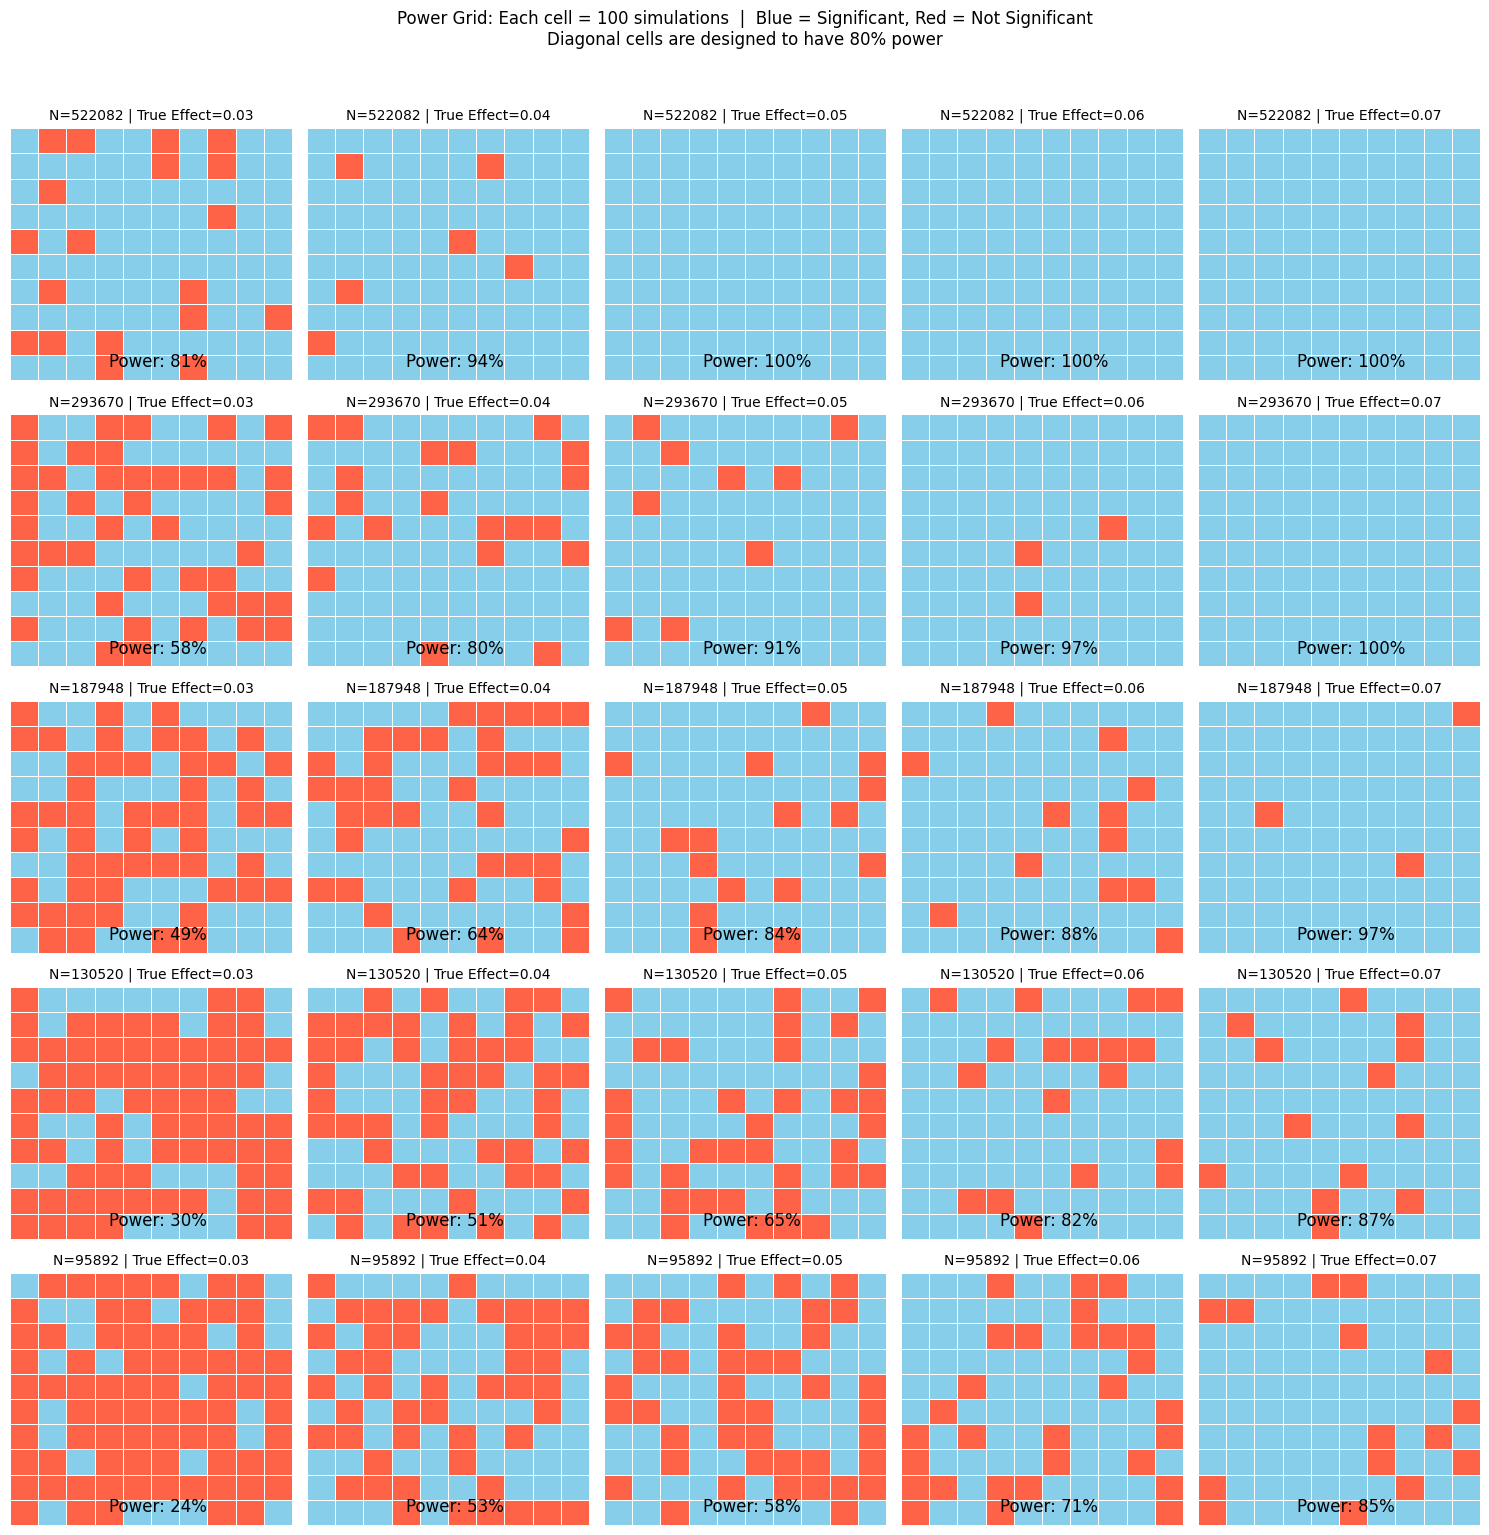

In [9]:
# --- Power Grid Heatmap ---
# Each subplot shows 100 simulations arranged in a 10x10 grid.
# Blue = significant, Red = not significant.
# Row = sample size (designed for each effect), Column = true effect size.
# The DIAGONAL cells should show ~80% blue (the target power).
# Off-diagonal cells reveal how power degrades when sample size is mismatched.

g = sns.FacetGrid(
    stats,
    col='true_effect',
    row='sample_size',
    height=3, aspect=1,
    row_order=sample_sizes
)
g.map_dataframe(
    draw_heatmap, row_var='index_row', col_var='index_col', value_var='sig_at',
    vmin=0, vmax=1, cmap=ListedColormap(['tomato', 'skyblue']),
    annot=False, linewidth=0.5, alpha=1, cbar=False
)
g.map_dataframe(annotate_power, metric='sig_at')

for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])

g.set_titles(row_template="N={row_name}", col_template="True Effect={col_name}")
g.figure.suptitle(
    "Power Grid: Each cell = 100 simulations  |  Blue = Significant, Red = Not Significant\n"
    "Diagonal cells are designed to have 80% power",
    y=1.02
)
g.figure.tight_layout()

---
## Section 4: Confidence Interval Behavior Across Experiments

### What CIs Tell Us About Statistical Power

A confidence interval (CI) provides more information than a binary significant/not-significant decision. Under repeated sampling:

- **Coverage**: (1−α)% of CIs contain the true effect
- **Width**: Reflects uncertainty — wider CIs indicate less precise estimates
- **Position relative to zero**: Determines significance (CI excludes 0 ↔ significant)

### How Power Relates to CI Position

For an experiment designed with 80% power at a 5% true effect:
- In ~80% of experiments: the entire CI will be **above zero** (correctly detecting the effect)
- In ~20% of experiments: the CI will **straddle zero** (false negative — missed the effect)
- The **CI lower bound** should cluster just above or around zero for a 80%-powered experiment

The plots below use one specific configuration: `true_effect = 5%`, `sample_size = n` designed for 5% effect.

Configuration: true effect = 5%, n per variant = 93,974
Observed power: 84.0% (84/100 significant)
Theoretical power: 80%


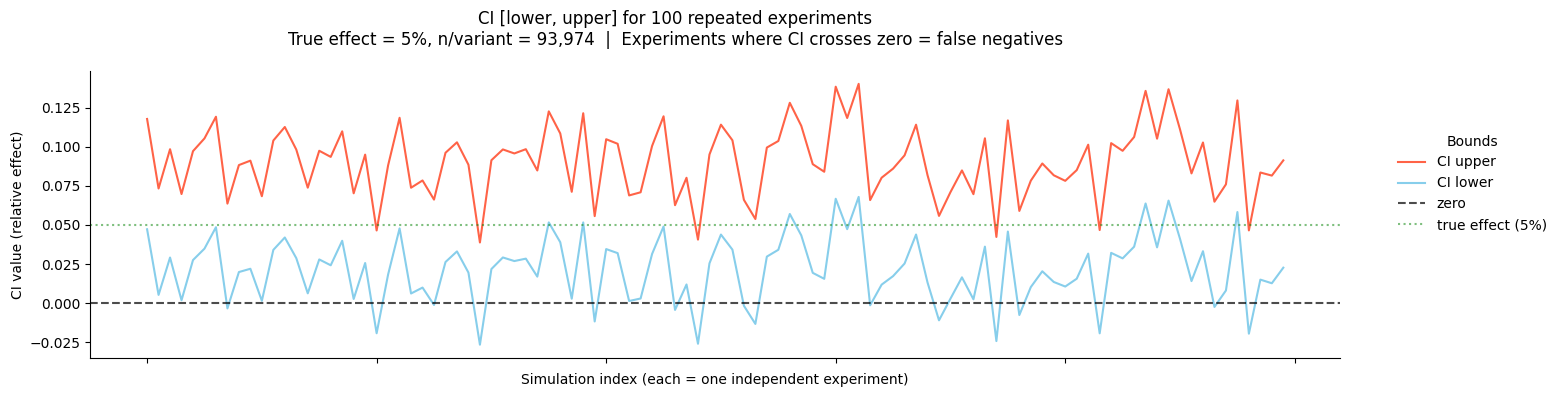

In [10]:
# Select one configuration: true effect = 5%, sample size designed for 5% effect
target_effect = 0.05
target_n = sample_sizes[EFFECT_SIZES.index(target_effect)]

stats_plot = stats.loc[
    (stats['true_effect'] == target_effect) & (stats['sample_size'] == target_n)
].copy().reset_index(drop=True)
stats_plot['index'] = stats_plot.index

print(f"Configuration: true effect = {target_effect:.0%}, n per variant = {target_n//2:,}")
print(f"Observed power: {stats_plot['sig_at'].mean():.1%} ({stats_plot['sig_at'].sum()}/{len(stats_plot)} significant)")
print(f"Theoretical power: {1-BETA:.0%}")

g = sns.FacetGrid(stats_plot, height=4, aspect=3)
g.map_dataframe(sns.lineplot, x='index', y='ci_h', color='tomato',  label='CI upper')
g.map_dataframe(sns.lineplot, x='index', y='ci_l', color='skyblue', label='CI lower')
g.refline(y=0,            color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='zero')
g.refline(y=target_effect, color='green', linestyle=':',  linewidth=1.5, alpha=0.5, label=f'true effect ({target_effect:.0%})')

for ax in g.axes.flatten():
    ax.set_xticklabels([])

g.set_axis_labels('Simulation index (each = one independent experiment)', 'CI value (relative effect)')
g.add_legend(title='Bounds', fontsize=10)
sns.move_legend(g, "upper right", bbox_to_anchor=(1.15, 0.7), frameon=False)
g.fig.suptitle(
    f"CI [lower, upper] for {len(stats_plot)} repeated experiments\n"
    f"True effect = {target_effect:.0%}, n/variant = {target_n//2:,}  |  Experiments where CI crosses zero = false negatives"
)
g.fig.tight_layout()

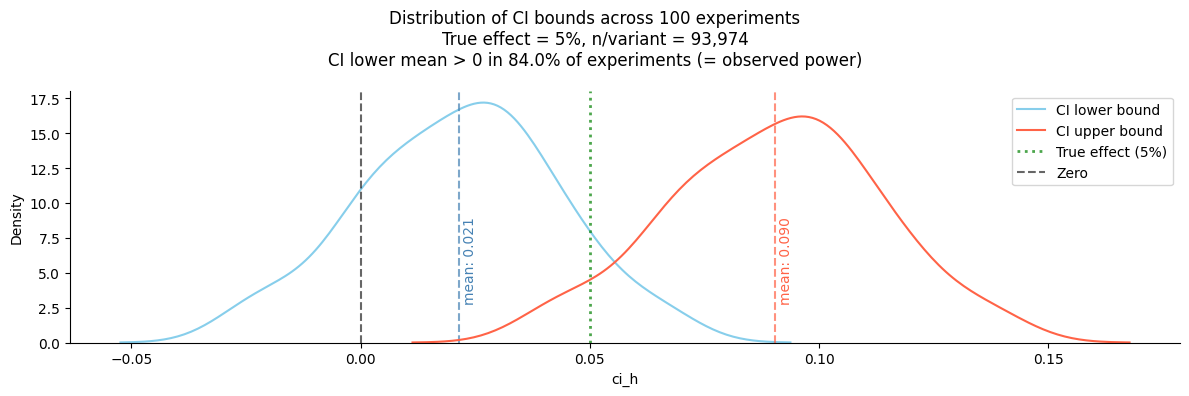

In [11]:
# --- KDE of CI bounds distribution ---
# For a well-powered experiment:
#   - ci_l should center just above 0 (the "margin" above which we detect)
#   - ci_h should center above the true effect
#   - The gap between mean(ci_l) and 0 reflects the signal-to-noise ratio

def vertical_mean_line(x, xal, yal, **kwargs):
    """Add a vertical dashed line at the mean of x with a text label."""
    plt.axvline(x.mean(), linestyle='--', color=kwargs.get('color', 'steelblue'), alpha=0.7)
    plt.text(x.mean() + xal, yal, f"mean: {x.mean():.3f}",
             size=10, color=kwargs.get('color', 'steelblue'), rotation=90)

g = sns.FacetGrid(stats_plot, height=4, aspect=3)

g.map(sns.kdeplot, 'ci_l', color='skyblue', label='CI lower bound')
g.map(vertical_mean_line, 'ci_l', xal=0.001, yal=3, color='steelblue')

g.map(sns.kdeplot, 'ci_h', color='tomato', label='CI upper bound')
g.map(vertical_mean_line, 'ci_h', xal=0.001, yal=3, color='tomato')

# Mark the true effect
for ax in g.axes.flatten():
    ax.axvline(target_effect, color='green', linestyle=':', linewidth=2, alpha=0.7,
               label=f'True effect ({target_effect:.0%})')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='Zero')
    ax.legend(fontsize=10)

g.fig.suptitle(
    f"Distribution of CI bounds across {len(stats_plot)} experiments\n"
    f"True effect = {target_effect:.0%}, n/variant = {target_n//2:,}\n"
    f"CI lower mean > 0 in {(stats_plot.ci_l > 0).mean():.1%} of experiments (= observed power)"
)
g.fig.tight_layout()

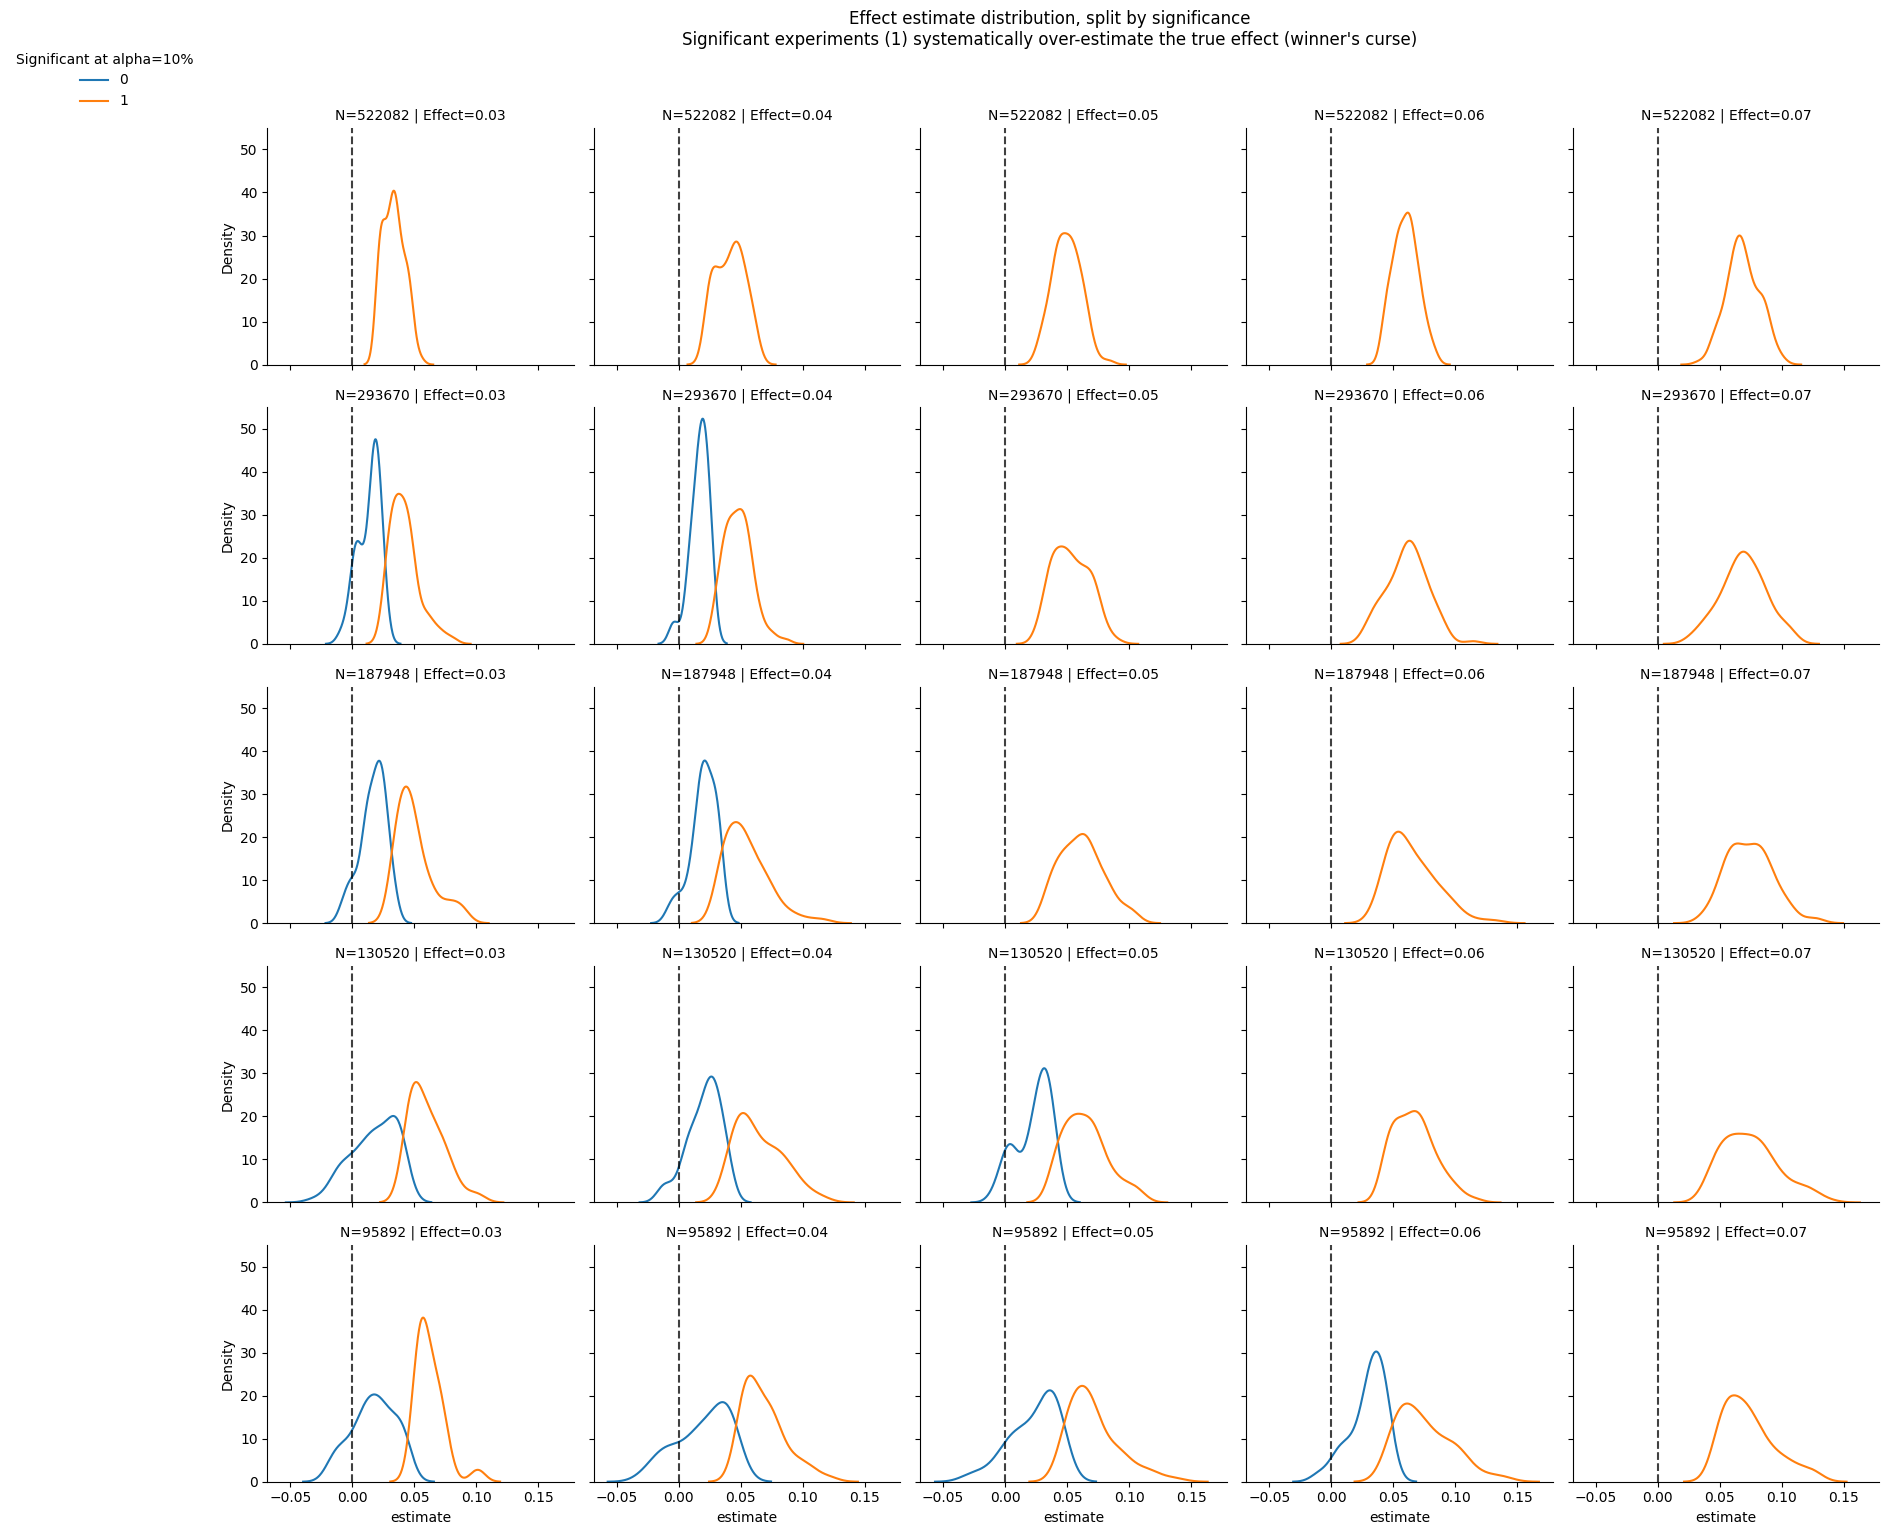

In [12]:
# --- Point estimate distribution split by significance ---
# This shows the 'winner's curse' / 'inflation bias':
# Significant experiments (blue) tend to have HIGHER estimates than the true effect,
# because only extreme samples cross the significance threshold.
# This is a form of selection bias in significance filtering.

plot_stats = stats.loc[stats['count_sig'] >= 20].copy()

g = sns.FacetGrid(
    plot_stats,
    col='true_effect', row='sample_size',
    hue='sig_at', height=3, aspect=1,
    sharex=True, row_order=sample_sizes
)
g.map(sns.kdeplot, 'estimate')
for ax in g.axes.flatten():
    ax.axvline(0, linestyle='--', color='black', alpha=0.75)

g.add_legend(title="Significant at alpha=10%")
sns.move_legend(g, "upper right", bbox_to_anchor=(0, 1), frameon=False)
g.set_titles(row_template="N={row_name}", col_template="Effect={col_name}")
g.figure.suptitle(
    "Effect estimate distribution, split by significance\n"
    "Significant experiments (1) systematically over-estimate the true effect (winner's curse)",
    y=1.02
)
g.figure.tight_layout()

---
## Section 5: Non-parametric Testing — Mann-Whitney U

### When to Use the Mann-Whitney U Test

The z-test / t-test for proportions relies on the Central Limit Theorem (CLT): for large enough samples, the sample mean is approximately normally distributed. However, for:
- **Heavily skewed distributions** (e.g., revenue, session duration, order value)
- **Distributions with heavy tails** (e.g., lognormal, Pareto)
- **Small samples** where CLT hasn't kicked in yet

...the normal approximation can be poor and the standard t-test may understate uncertainty.

The **Mann-Whitney U test** (also called the Wilcoxon rank-sum test) is a non-parametric alternative that:
1. Tests whether one distribution **stochastically dominates** the other (H₀: P(X > Y) = 0.5)
2. Makes **no distributional assumptions** beyond continuity
3. Is robust to outliers and heavy tails
4. Has slightly lower power than the t-test when data is truly normal (~95% efficiency)

**Limitation**: The Mann-Whitney U test doesn't directly test for a difference in means — it tests for a difference in the full distribution. For revenue/conversion metrics this is often what we want.

### Simulation Setup

We generate a lognormal metric (common for revenue / session time) with a small shift in the mean parameter (μ₀ = 1.02 vs μ₁ = 1.05) and identical spread (σ = 0.5). This represents a realistic scenario where treatment slightly increases average revenue but the distribution is right-skewed.

In [13]:
def vertical_plot_lines(x, xal, yal, **kwargs):
    """Add a vertical dashed mean line with label to a seaborn FacetGrid map."""
    plt.axvline(x.mean(), linestyle='--', color=kwargs.get('color', 'steelblue'), alpha=0.5)
    plt.text(x.mean() + xal, yal, f"mean: {x.mean():.2f}",
             size=11, color=kwargs.get('color', 'steelblue'), rotation=90)


def plot_distribution(df, metric, **kwargs):
    """Plot KDE of metric by variant with mean lines."""
    g = sns.FacetGrid(data=df, aspect=3, height=5, hue='variant', row=kwargs.get('row', None))
    g.map(sns.kdeplot, metric)
    g.map(vertical_plot_lines, metric, xal=kwargs.get('xal', 0.10), yal=kwargs.get('yal', 0.5))
    g.fig.suptitle(f"Distribution between variants — {metric}")
    g.set_xlabels(metric)
    g.set_ylabels("density")
    g.set(xlim=kwargs.get('xlim', (0, 20)))
    g.add_legend()
    plt.subplots_adjust(top=0.9)
    for ax in g.axes:
        ax[0].axvline(x=0, color='black', ls=':')

Theoretical E[control]   = 3.1424
Theoretical E[treatment] = 3.2381
Theoretical relative difference = 3.05%

Observed control mean:   3.1421
Observed treatment mean: 3.2331


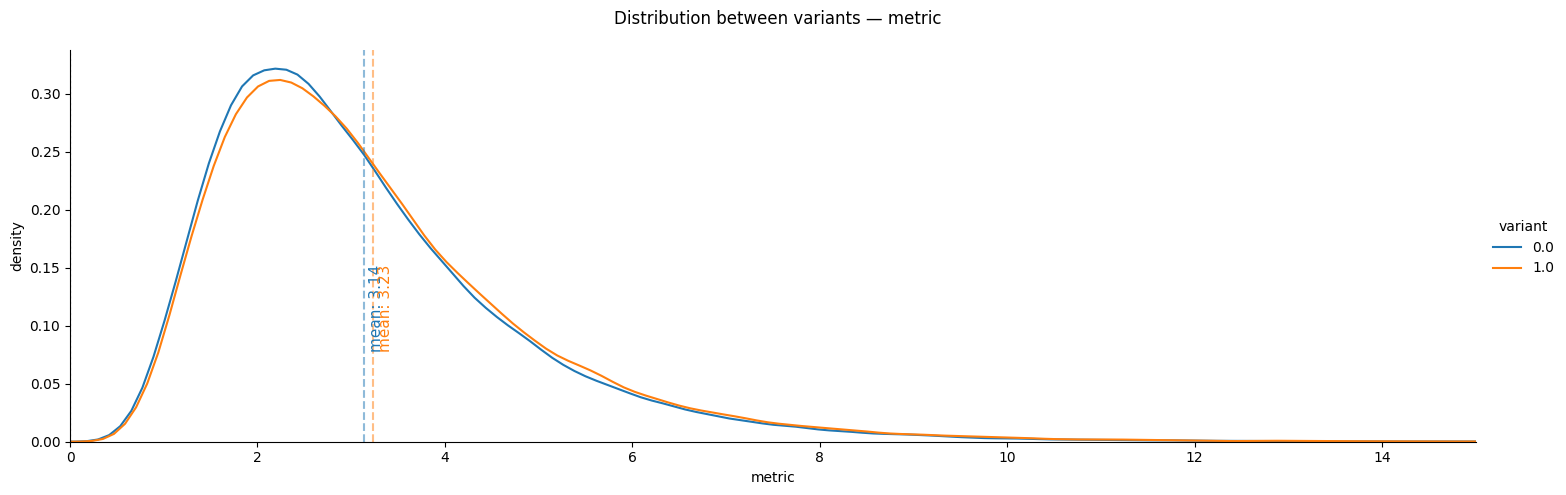

In [14]:
SAMPLE_SIZE = 250_000

# Lognormal revenue metric: log(X) ~ N(mu, sigma)
# E[X] = exp(mu + sigma^2/2), so a small increase in mu shifts the mean
MU_CONTROL   = 1.02
MU_TREATMENT = 1.05
SIGMA        = 0.50

np.random.seed(42)
df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0, 1, SAMPLE_SIZE))})
df_exp['metric'] = np.random.lognormal(MU_CONTROL, SIGMA, SAMPLE_SIZE)
df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.lognormal(
    MU_TREATMENT, SIGMA, int((df_exp.variant == 1).sum())
)

# Theoretical means: E[lognormal(mu, sigma)] = exp(mu + sigma^2/2)
mean_control   = np.exp(MU_CONTROL   + SIGMA**2 / 2)
mean_treatment = np.exp(MU_TREATMENT + SIGMA**2 / 2)
print(f"Theoretical E[control]   = {mean_control:.4f}")
print(f"Theoretical E[treatment] = {mean_treatment:.4f}")
print(f"Theoretical relative difference = {mean_treatment/mean_control - 1:.2%}")
print()
print(f"Observed control mean:   {df_exp.loc[df_exp.variant == 0, 'metric'].mean():.4f}")
print(f"Observed treatment mean: {df_exp.loc[df_exp.variant == 1, 'metric'].mean():.4f}")

plot_distribution(df_exp, 'metric', xlim=(0, 15), yal=0.08, xal=0.05)

In [15]:
# Mann-Whitney U test: H0 = P(treatment > control) = 0.5
# A significant result means the treatment distribution stochastically dominates the control.
CONFIDENCE = 0.90

array_control   = df_exp.loc[df_exp.variant == 0, 'metric'].values
array_treatment = df_exp.loc[df_exp.variant == 1, 'metric'].values

u_stat, p_value = mannwhitneyu(array_control, array_treatment, alternative='two-sided')

print(f"Mann-Whitney U statistic:  {u_stat:,.0f}")
print(f"p-value (two-sided):       {p_value:.2e}")
print(f"Significant at {1-CONFIDENCE:.0%} level:    {p_value < (1 - CONFIDENCE)}")
print()
print("Interpretation:")
print(f"  The treatment distribution stochastically dominates the control (p = {p_value:.2e}).")
print(f"  Note: U / (n0 * n1) = {u_stat / (len(array_control) * len(array_treatment)):.4f}")
print(f"  This is P(treatment > control) = {u_stat / (len(array_control) * len(array_treatment)):.4f}")
print(f"  (Under H0 this would be exactly 0.5)")

Mann-Whitney U statistic:  7,570,293,893
p-value (two-sided):       4.43e-41
Significant at 10% level:    True

Interpretation:
  The treatment distribution stochastically dominates the control (p = 4.43e-41).
  Note: U / (n0 * n1) = 0.4845
  This is P(treatment > control) = 0.4845
  (Under H0 this would be exactly 0.5)


---
## Section 6: A/A Testing, False Positive Rate & Optional Stopping

### What is an A/A Test?

An **A/A test** is an experiment where both groups receive *identical* treatment (the "variant" is a fake variant with no effect). A properly calibrated statistical test should:
- Produce a p-value that is **uniformly distributed** on [0, 1] under H₀
- Yield a false positive rate exactly equal to α (e.g., 10% of A/A tests should appear significant at α = 10%)

A/A tests are used to:
1. Validate that the testing infrastructure and randomization are working correctly
2. Confirm that the p-value is well-calibrated (no systematic bias in assignment or measurement)
3. Check that variance estimates are accurate

### The Danger of Optional Stopping ("Peeking")

A tempting — but statistically invalid — practice is to **extend an experiment when it is "trending"** (i.e., the CI lower bound is just below zero but close to it). The intuition is: "the effect is almost there, let's collect more data."

This is a form of **optional stopping** (also called sequential testing without correction), which:
1. **Inflates the false positive rate** far above the nominal α level
2. Is equivalent to running a multiple comparison without correction
3. Violates the fixed-horizon testing assumption

**The simulation below demonstrates this empirically:**
- We run 1,000 A/A simulations (no true effect)
- When a result is "trending" (ci_l ∈ [−0.01, 0)), we extend the experiment by doubling the sample
- We track how often the extended experiment then appears significant

**Expected calibration:** At α = 10%, exactly ~10% of A/A tests should be significant.

In [16]:
def run_aa_simulation(
    num_simulations=1000,
    sample_size=100_000,
    true_effect=0.0,
    base_rate=0.05,
    alpha=0.10,
    ci_l_threshold=-0.01,
    confidence=0.90
):
    """
    Run A/A (or A/B) simulations to measure false positive rate and peeking inflation.

    For each simulation:
    1. Generate a binary experiment with `true_effect` (0.0 for A/A)
    2. Analyze it and record the result
    3. If the CI lower bound falls in the 'trending' zone (ci_l_threshold < ci_l <= 0),
       collect a second batch and re-analyze the combined data (simulating peeking)
    4. Track how often peeking flips a trending result to significant

    Parameters
    ----------
    num_simulations : int
        Number of independent experiment runs.
    sample_size : int
        Total experiment sample size (split 50/50 between variants).
    true_effect : float
        True relative uplift; 0.0 for A/A tests.
    base_rate : float
        Baseline conversion rate.
    alpha : float
        Significance threshold.
    ci_l_threshold : float
        Lower bound of the 'trending' window. Results with ci_l in
        (ci_l_threshold, 0] are considered 'trending' and get a second batch.
    confidence : float
        Confidence level for CI construction (should be 1 - alpha).

    Returns
    -------
    stats : pd.DataFrame
        Per-simulation results with estimate, ci_l, ci_h, p-value, sig_at.
    counter_trending : int
        Number of simulations that were 'trending' and received a second batch.
    counter_result_changed : int
        Number of trending simulations that became significant after the second batch.
    """
    counter_trending = 0
    counter_result_changed = 0
    responses = {}

    for i in tqdm(range(num_simulations), desc="A/A simulations"):
        # --- First batch ---
        df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0, 1, sample_size))})
        df_exp['metric'] = np.random.binomial(n=1, p=base_rate, size=sample_size)
        df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
            n=1,
            p=base_rate * (1 + true_effect),
            size=int((df_exp.variant == 1).sum())
        )
        response = run_single_experiment_silent(df_exp, confidence=confidence)

        # --- Peeking: extend if 'trending' (ci_l just below zero) ---
        if ci_l_threshold < response['ci_l'] <= 0:
            counter_trending += 1

            df_exp_2 = pd.DataFrame({'variant': np.round(np.random.uniform(0, 1, sample_size))})
            df_exp_2['metric'] = np.random.binomial(n=1, p=base_rate, size=sample_size)
            df_exp_2.loc[df_exp_2.variant == 1, 'metric'] = np.random.binomial(
                n=1,
                p=base_rate * (1 + true_effect),
                size=int((df_exp_2.variant == 1).sum())
            )

            # Re-analyze with doubled sample
            response_extended = run_single_experiment_silent(
                pd.concat([df_exp, df_exp_2]), confidence=confidence
            )
            if response_extended['ci_l'] > 0:
                counter_result_changed += 1

        response['true_effect'] = true_effect
        response['sample_size'] = sample_size
        response['index_row']   = int(i // 10)
        response['index_col']   = int(i % 10)
        responses[i] = response

    result = pd.DataFrame(responses).T
    result['sample_size'] = result['sample_size'].astype(int)
    result['sig_at'] = (result['p-value'] <= alpha).astype(int)
    result['count_sig'] = result.groupby(['true_effect', 'sample_size', 'sig_at'])['sig_at'].transform('count')

    return result, counter_trending, counter_result_changed

In [17]:
N_AA_SIMS = 1000
ALPHA_AA  = 0.10   # significance level for A/A validation

aa_stats, counter_trending, counter_result_changed = run_aa_simulation(
    num_simulations=N_AA_SIMS,
    sample_size=100_000,
    true_effect=0.0,       # A/A: no real effect
    base_rate=0.05,
    alpha=ALPHA_AA,
    ci_l_threshold=-0.01,
    confidence=1 - ALPHA_AA
)

A/A simulations: 100%|██████████| 1000/1000 [00:07<00:00, 132.35it/s]


In [18]:
print("=" * 55)
print("A/A TEST RESULTS (no true effect)")
print("=" * 55)
print(f"Total simulations:          {N_AA_SIMS:,}")
print(f"Nominal alpha:              {ALPHA_AA:.0%}")
print(f"Observed false positive rate: {aa_stats['sig_at'].mean():.2%}")
print(f"Expected false positive rate: {ALPHA_AA:.2%}")
print()
print("--- PEEKING ANALYSIS ---")
print(f"Trending results (ci_l in (-0.01, 0]):  {counter_trending} ({counter_trending/N_AA_SIMS:.2%} of simulations)")
print(f"Flipped to significant after peeking:   {counter_result_changed} ({counter_result_changed/N_AA_SIMS:.2%} of ALL simulations)")
if counter_trending > 0:
    print(f"Conditional flip rate | trending:        {counter_result_changed/counter_trending:.2%}")
    print()
    print("Interpretation: Of all A/A experiments that 'looked like they were working',")
    print(f"  {counter_result_changed/counter_trending:.1%} would have appeared significant if we had extended them.")
    print("  This is NOT a real effect — it is pure false positive inflation from peeking.")

A/A TEST RESULTS (no true effect)
Total simulations:          1,000
Nominal alpha:              10%
Observed false positive rate: 10.10%
Expected false positive rate: 10.00%

--- PEEKING ANALYSIS ---
Trending results (ci_l in (-0.01, 0]):  49 (4.90% of simulations)
Flipped to significant after peeking:   15 (1.50% of ALL simulations)
Conditional flip rate | trending:        30.61%

Interpretation: Of all A/A experiments that 'looked like they were working',
  30.6% would have appeared significant if we had extended them.
  This is NOT a real effect — it is pure false positive inflation from peeking.


### Statistical Validation: False Positive Rate Calibration

With 1,000 A/A simulations and α = 10%, the expected number of false positives is **100** (Binomial(1000, 0.10)). The 95% CI around this expectation is approximately:

$$\text{95\% CI} = 100 \pm 1.96 \sqrt{1000 \times 0.10 \times 0.90} \approx [81, 119]$$

So we should see between 81 and 119 false positives in 1,000 A/A simulations for the test to be well-calibrated. The cell below verifies this with a formal binomial test.

In [19]:
observed_fp = aa_stats['sig_at'].sum()
total_sims  = len(aa_stats)
expected_fp = total_sims * ALPHA_AA

# Exact binomial test: H0 = false positive rate equals alpha
# scipy >= 1.7 deprecated binom_test; >= 1.12 removed it in favour of binomtest
try:
    from scipy.stats import binom_test
    p_calibration = binom_test(observed_fp, total_sims, ALPHA_AA, alternative='two-sided')
except (ImportError, AttributeError):
    from scipy.stats import binomtest
    p_calibration = binomtest(observed_fp, total_sims, ALPHA_AA, alternative='two-sided').pvalue

# 95% Wilson CI for the true false positive rate
from statsmodels.stats.proportion import proportion_confint
ci_lo, ci_hi = proportion_confint(observed_fp, total_sims, alpha=0.05, method='wilson')

print("FALSE POSITIVE RATE CALIBRATION CHECK")
print("=" * 45)
print(f"Observed false positives:  {observed_fp} / {total_sims}  ({observed_fp/total_sims:.2%})")
print(f"Expected false positives:  {expected_fp:.0f} / {total_sims}  ({ALPHA_AA:.2%})")
print(f"95% CI for observed rate:  [{ci_lo:.2%}, {ci_hi:.2%}]")
print(f"Binomial test p-value:     {p_calibration:.4f}")
print()
if p_calibration > 0.05:
    print(f"PASS: Cannot reject H0 (p = {p_calibration:.4f} > 0.05).")
    print("The test is well-calibrated — the false positive rate matches the nominal alpha.")
else:
    print(f"FAIL: Reject H0 (p = {p_calibration:.4f} < 0.05).")
    print("The test is NOT well-calibrated — investigate the test procedure.")

# Additional context: Monte Carlo uncertainty
mc_se = np.sqrt(ALPHA_AA * (1 - ALPHA_AA) / total_sims)
print(f"\nMonte Carlo SE (expected): {mc_se:.3f}  ({mc_se/ALPHA_AA:.1%} relative)")
print(f"The 2-SE range around the target is [{ALPHA_AA - 2*mc_se:.2%}, {ALPHA_AA + 2*mc_se:.2%}]")

FALSE POSITIVE RATE CALIBRATION CHECK
Observed false positives:  101 / 1000  (10.10%)
Expected false positives:  100 / 1000  (10.00%)
95% CI for observed rate:  [8.38%, 12.12%]
Binomial test p-value:     0.9160

PASS: Cannot reject H0 (p = 0.9160 > 0.05).
The test is well-calibrated — the false positive rate matches the nominal alpha.

Monte Carlo SE (expected): 0.009  (9.5% relative)
The 2-SE range around the target is [8.10%, 11.90%]


In [20]:
# Summary statistics of A/A results
# Under H0 (no true effect), p-values should be uniform on [0,1].
# If the test is calibrated:
#   - mean(p-value) ≈ 0.50  (mean of Uniform[0,1])
#   - mean(estimate) ≈ 0.0  (centered around zero)
#   - mean(ci_l) ≈ -mean(ci_h)  (symmetric CIs around zero)

print("Descriptive statistics of A/A simulation results:")
print(aa_stats[['estimate', 'ci_l', 'ci_h', 'p-value']].describe().round(4))
print()
print(f"P-value uniformity check:")
print(f"  Mean p-value: {aa_stats['p-value'].mean():.4f}  (expected: 0.50 for Uniform[0,1])")
print(f"  Std  p-value: {aa_stats['p-value'].std():.4f}  (expected: {1/np.sqrt(12):.4f} for Uniform[0,1])")

# Fraction of CIs that exclude zero (= observed false positive rate at different thresholds)
print(f"\nFalse positive rates at different CI bounds thresholds:")
print(f"  CI excludes 0 exactly (|delta| > 0):      {((aa_stats.ci_l > 0) | (aa_stats.ci_h < 0)).mean():.3%}  (= nominal alpha {ALPHA_AA:.0%})")
print(f"  CI excludes (-1%, +1%) range:             {((aa_stats.ci_l > -0.01) | (aa_stats.ci_h < 0.01)).mean():.3%}")
print(f"  CI excludes (-2%, +2%) range:             {((aa_stats.ci_l > -0.02) | (aa_stats.ci_h < 0.02)).mean():.3%}")

Descriptive statistics of A/A simulation results:
        estimate       ci_l       ci_h    p-value
count  1000.0000  1000.0000  1000.0000  1000.0000
mean     -0.0004    -0.0448     0.0460     0.4866
std       0.0277     0.0265     0.0290     0.2833
min      -0.1082    -0.1481    -0.0666     0.0000
25%      -0.0197    -0.0634     0.0258     0.2416
50%      -0.0022    -0.0465     0.0439     0.4750
75%       0.0193    -0.0261     0.0666     0.7177
max       0.0841     0.0365     0.1341     0.9971

P-value uniformity check:
  Mean p-value: 0.4866  (expected: 0.50 for Uniform[0,1])
  Std  p-value: 0.2833  (expected: 0.2887 for Uniform[0,1])

False positive rates at different CI bounds thresholds:
  CI excludes 0 exactly (|delta| > 0):      10.100%  (= nominal alpha 10%)
  CI excludes (-1%, +1%) range:             19.600%
  CI excludes (-2%, +2%) range:             37.800%


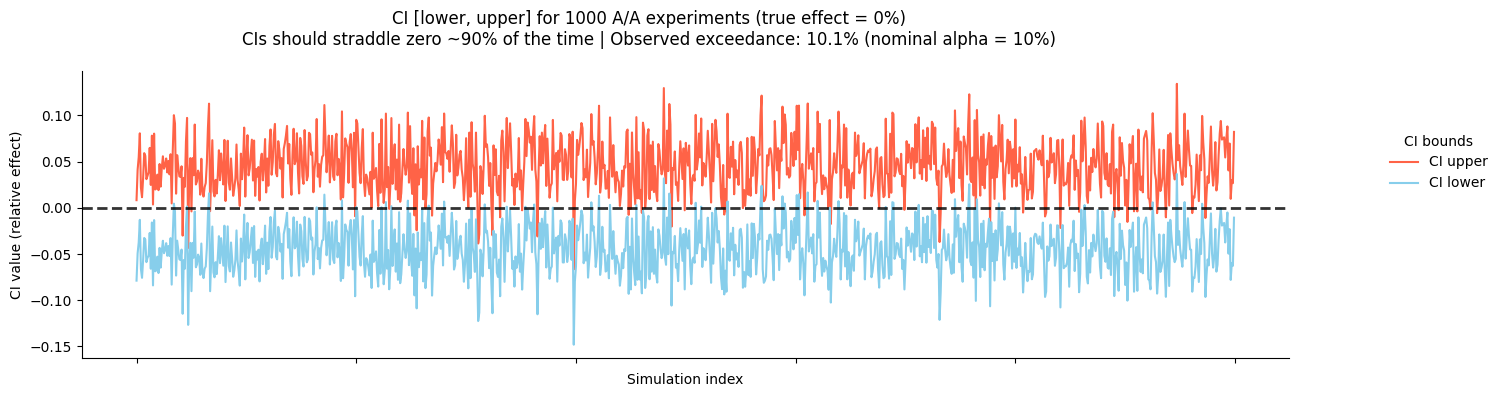

In [21]:
# CI time series for A/A test
# Under H0, CIs should randomly straddle zero.
# Red (ci_l > 0 or ci_h < 0) = false positive
aa_stats_plot = aa_stats.copy().reset_index(drop=True)
aa_stats_plot['index'] = aa_stats_plot.index

g = sns.FacetGrid(aa_stats_plot, height=4, aspect=3)
g.map_dataframe(sns.lineplot, x='index', y='ci_h', color='tomato',  label='CI upper')
g.map_dataframe(sns.lineplot, x='index', y='ci_l', color='skyblue', label='CI lower')
g.refline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.8)

for ax in g.axes.flatten():
    ax.set_xticklabels([])

g.set_axis_labels('Simulation index', 'CI value (relative effect)')
g.add_legend(title='CI bounds', fontsize=10)
sns.move_legend(g, "upper right", bbox_to_anchor=(1.15, 0.7), frameon=False)
g.fig.suptitle(
    f"CI [lower, upper] for {N_AA_SIMS} A/A experiments (true effect = 0%)\n"
    f"CIs should straddle zero ~{(1-ALPHA_AA):.0%} of the time | "
    f"Observed exceedance: {aa_stats['sig_at'].mean():.1%} (nominal alpha = {ALPHA_AA:.0%})"
)
g.fig.tight_layout()

---
## Summary & Key Takeaways

### 1. Power & Sample Size
- The analytical formula `n = 2σ²(z_{α/2} + z_β)² / Δ²` reliably predicts the sample size needed to achieve a target power
- **Simulation confirms**: running at the analytically-derived sample size yields ~80% significant results when the true effect equals the MDE
- Power scales poorly with small MDEs — halving the MDE requires **4× more data**

### 2. Confidence Interval Behavior
- CIs from repeated well-powered experiments cluster around the true effect
- **Winner's curse**: significant experiments systematically **over-estimate** the true effect because significance filtering selects extreme samples
- The lower CI bound is the key decision variable: power = fraction of experiments where ci_l > 0

### 3. Non-parametric Testing
- The Mann-Whitney U test is appropriate for heavy-tailed metrics (revenue, session time)
- At large sample sizes, both parametric and non-parametric tests are consistent, but Mann-Whitney is more robust for skewed distributions
- The test statistic U/n₀n₁ estimates P(treatment > control), a directly interpretable quantity

### 4. A/A Testing & False Positive Rate
- A correctly implemented test produces a **uniform p-value distribution** under H₀
- At α = 10%, ~10% of A/A tests appear significant — this is expected and correct, not a bug
- **Peeking (optional stopping) inflates false positives**: extending a trending experiment uses up part of the α budget and should not be done without sequential testing corrections (e.g., alpha spending functions, SPRT, Bayesian methods)

### Recommendations for Production A/B Testing
1. **Pre-register** sample size, primary metric, and stopping criterion before the experiment starts
2. **Never peek and extend** — use a sequential testing framework if early stopping is needed
3. **Run A/A tests** regularly to validate test infrastructure calibration
4. **Report effect estimates with CIs**, not just significance — a barely-significant result at the exact MDE is much weaker evidence than a result 3× the MDE
5. For **skewed metrics** (revenue, engagement time), consider Mann-Whitney or log-transforming before t-test